Serial repetition CRP curves for repeated-item transitions in serial recall.

This notebook compares mixed (lag > 0) trials against a shuffled control
(lag == 0) using RepeatedRecallsGordonRanschburg2021. Each plot shows
first vs second presentation curves within a single dataset.


In [1]:
import os

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.serialrepcrp import plot_rep_crp, subject_serial_rep_crp, test_serial_rep_crp_vs_control
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
allow_repeated_recalls = True
filter_repeated_recalls = False
data_path = "data/RepeatedRecallsGordonRanschburg2021.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
base_data_name = "GordonRanschburg2021"
trial_query = "data['condition'] == 2"
mixed_trial_query = "jnp.logical_and(data['condition'] == 2, data['lag'] != 4)"
control_trial_query = "jnp.logical_and(data['condition'] == 2, data['lag'] == 4)"
control_shuffles = 10
control_seed = 0
min_lag = 2
max_lag = 3
size = 2


In [3]:
# Parameters
data_path = "projects/repfr/results/simulations/RepeatedRecallsGordonRanschburg2021_McfReinfPositionalCMRNoStop_rerun_best_of_1.h5"
figure_dir = "projects/repfr/results/figures/fitting"
figure_str = "RepeatedRecallsGordonRanschburg2021_McfReinfPositionalCMRNoStop_rerun_best_of_1_serialrepcrp.png"
mixed_trial_query = "jnp.logical_and(data['condition'] == 2, data['lag'] != 4)"
control_trial_query = "jnp.logical_and(data['condition'] == 2, data['lag'] == 4)"
control_shuffles = 1
trial_query = "data['condition'] == 2"


In [4]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)
mixed_mask = generate_trial_mask(data, mixed_trial_query) & trial_mask

control_dataset = make_control_dataset(
    data,
    mixed_query=mixed_trial_query,
    control_query=control_trial_query,
    n_shuffles=control_shuffles,
    remove_repeats=filter_repeated_recalls,
    seed=control_seed,
)
control_mask = jnp.ones((control_dataset["recalls"].shape[0],), dtype=bool)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 577, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/jupyter_client/session.py", line 993, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", 

Bad pipe message: %s [b'\xbe\xe4\xc9\xbb\xd7\x04\xb2>\xaa\xd0\x9f\xae\x04A2\x87\xad\x7f \x1di"\xc3\xdc\xd5\x0e\x81\xde\xb0p9\x8a\xfc\x0c\xf1\xe9D!\xc8\xd9\x91\x7fg#\x8b(\x9bjM\xb8k\x00*zz\x13\x02\x13\x03', b'\xc0,\xc0+\xcc\xa9\xc00\xc0/\xcc\xa8\xc0\n\xc0\t\xc0\x14', b"\x00\x9d\x00\x9c\x005\x00/\xc0\x08\xc0\x12\x00\n\x01\x00\x05n\xaa\xaa\x00\x00\x00\x17\x00\x00\xff\x01\x00\x01\x00\x00\n\x00\x0e\x00\x0cZZ\x11\xec\x00\x1d\x00\x17\x00\x18\x00\x19\x00\x0b\x00\x02\x01\x00\x00\x10\x00\x0e\x00\x0c\x02h2\x08http/1.1\x00\x05\x00\x05\x01\x00\x00\x00\x00\x00\r\x00\x16\x00\x14\x04\x03\x08\x04\x04\x01\x05\x03\x08\x05\x08\x05\x05\x01\x08\x06\x06\x01\x02\x01\x00\x12\x00\x00\x003\x04\xef\x04\xedZZ\x00\x01\x00\x11\xec\x04\xc0\x1eG\x11/\x04u`\x92\x87'\xdb\x89YuGj!1{\xdc]\xae\xc2\xce\xeb\x10\x0b\x96\xc4\x84\xd5\xcc\x9a H\xc4\xd2\xf6E\x91AM\xe3\xb5c\n\xf0N\x10&\x95\xb3\xc2\x18\x17wO\xa6<\x03\xf8\xe9qY", b"\xc9\x88\x9a\xd0|\xa7\x02\xd8\xbb\tl\x84\xd2ww\x05\x8a\x0f\xa2\x8aA`ik\x85\xc0F\xf4\xd8\xa5\\\xd7\xa5^

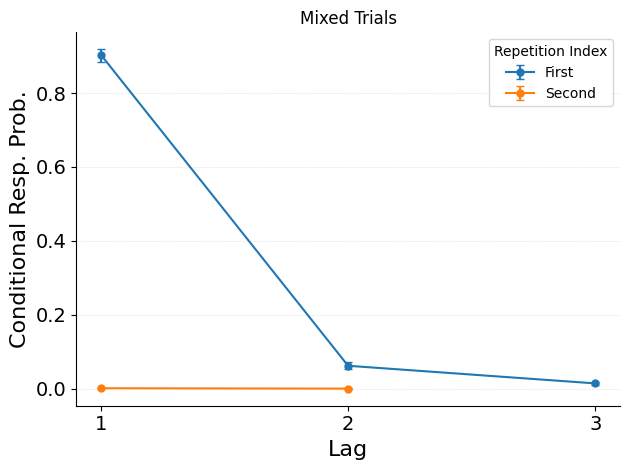

/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


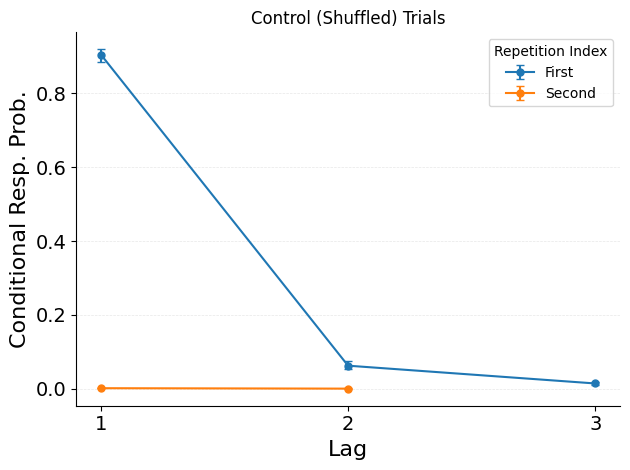

In [5]:
plot_rep_crp(
    datasets=data,
    trial_masks=mixed_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plt.title("Mixed Trials")
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")

plot_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plt.title("Control (Shuffled) Trials")
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")


In [6]:
observed_crp = subject_serial_rep_crp(data, mixed_mask, min_lag, max_lag, size)
control_crp = subject_serial_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_serial_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print()
    print("=" * 60)
    print(f"Statistical Tests: {label}")
    print("=" * 60)
    print(result)


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 577, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/jupyter_client/session.py", line 993, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", 


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
    1 |   -0.902     0.3762 |    136.0     0.7048 |    -0.0012
    2 |   -0.137     0.8919 |    141.0     0.8115 |    -0.0001
    3 |    0.628     0.5361 |    133.0     0.6431 |     0.0003

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
    1 |    0.851     0.4035 |    112.0     0.4291 |     0.0001
    2 |    1.197     0.2434 |     36.0     0.3003 |     0.0002
    3 |      nan        nan |      nan        nan |        nan


/Users/jordangunn/jaxcmr/jaxcmr/analyses/serialrepcrp.py:515: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/serialrepcrp.py:526: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)
